# R01 — Win/Loss Rates per Opponent

**Goal:** Understand how our Autopilot robot performs against each opponent.
We look at win rate, net damage, and hit rates to identify weak matchups.

- **Win rate**: Fraction of rounds we won (0.5 = evenly matched)
- **Net damage**: Damage dealt − received per round (positive = winning)
- **Hit rates**: Our accuracy vs how often they hit us

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

scores = load_local_scores()
scores = add_opponent_names(scores)
print(f'Loaded {len(scores):,} score rows from Autopilot perspective')
print(f'Opponents: {sorted(scores["opponent_name"].unique())}')

Indexed 60 ticks.csv files across 7 distinct robots from 1 root(s).
Selected 7 robots × ~100 battles = 60 (battle, robot) pairs to load.
Loaded 60 scores.csv files → 2,100 rows × 17 cols, 7 robots (~0.4 MB)
Loaded 1,050 score rows from Autopilot perspective
Opponents: ['Ahab 1.0', 'Gilgalad 1.99.5c', 'Pequod 1.0', 'Roborio 1.2.4', 'Shadow 3.83c', 'Tungsten 1.0a', 'Unknown']


In [2]:
# Per-opponent summary
opp_stats = scores.groupby('opponent_name').agg(
    rounds=('round', 'count'),
    avg_win_rate=('win_rate', 'mean'),
    avg_dmg_dealt=('damage_dealt', 'mean'),
    avg_dmg_received=('damage_received', 'mean'),
    avg_our_hr=('our_hit_rate', 'mean'),
    avg_opp_hr=('opponent_hit_rate', 'mean'),
).reset_index()
opp_stats['avg_net_damage'] = opp_stats['avg_dmg_dealt'] - opp_stats['avg_dmg_received']
opp_stats = opp_stats.sort_values('avg_net_damage', ascending=True)
print(opp_stats.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

   opponent_name  rounds  avg_win_rate  avg_dmg_dealt  avg_dmg_received  avg_our_hr  avg_opp_hr  avg_net_damage
    Shadow 3.83c     140         0.000          1.639            92.124       0.034       0.665         -90.486
      Pequod 1.0     175         0.000          7.261            87.371       0.087       0.475         -80.110
         Unknown      35         0.000          1.337            80.149       0.032       0.447         -78.811
Gilgalad 1.99.5c     175         0.000          3.506            79.846       0.037       0.422         -76.340
   Roborio 1.2.4     175         0.000          7.111            73.096       0.056       0.320         -65.986
   Tungsten 1.0a     175         0.000          7.824            73.480       0.067       0.287         -65.656
        Ahab 1.0     175         0.000         12.173            68.176       0.077       0.283         -56.004


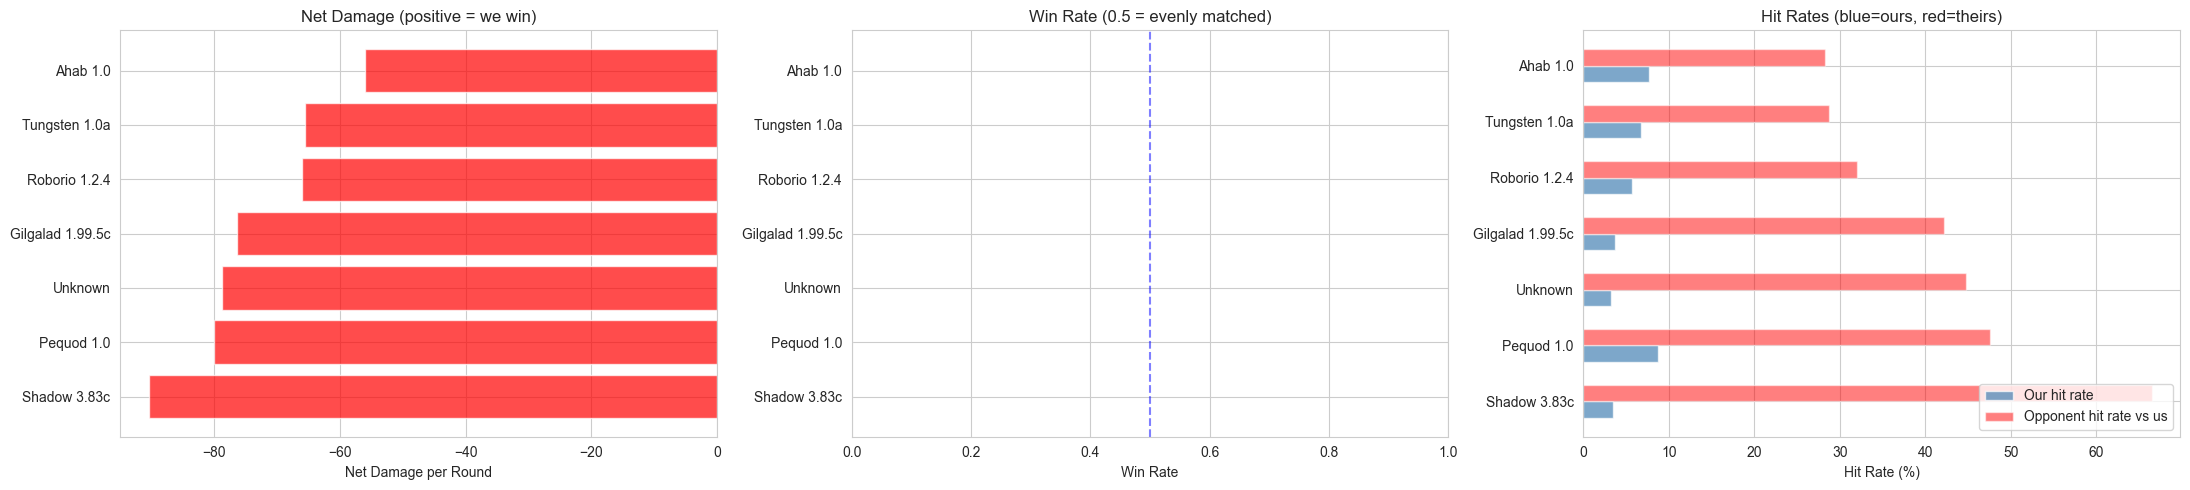

In [3]:
# Charts
fig, axes = plt.subplots(1, 3, figsize=(22, max(5, len(opp_stats)*0.6)))

# Net damage
ax = axes[0]
colors = ['green' if x > 0 else 'red' for x in opp_stats['avg_net_damage']]
ax.barh(opp_stats['opponent_name'], opp_stats['avg_net_damage'], color=colors, alpha=0.7)
ax.set_xlabel('Net Damage per Round')
ax.set_title('Net Damage (positive = we win)')
ax.axvline(x=0, color='black', linewidth=0.5)

# Win rate
ax = axes[1]
colors = ['green' if x > 0.5 else 'orange' if x > 0.3 else 'red' for x in opp_stats['avg_win_rate']]
ax.barh(opp_stats['opponent_name'], opp_stats['avg_win_rate'], color=colors, alpha=0.7)
ax.set_xlabel('Win Rate')
ax.set_title('Win Rate (0.5 = evenly matched)')
ax.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1)

# Hit rates
ax = axes[2]
x = range(len(opp_stats))
ax.barh([i - 0.15 for i in x], opp_stats['avg_our_hr']*100, height=0.3, color='steelblue', alpha=0.7, label='Our hit rate')
ax.barh([i + 0.15 for i in x], opp_stats['avg_opp_hr']*100, height=0.3, color='red', alpha=0.5, label='Opponent hit rate vs us')
ax.set_yticks(list(x))
ax.set_yticklabels(opp_stats['opponent_name'])
ax.set_xlabel('Hit Rate (%)')
ax.set_title('Hit Rates (blue=ours, red=theirs)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [4]:
# Overall summary
print(f'=== Overall Performance ===')
print(f'Total opponents: {len(opp_stats)}')
print(f'Total rounds: {len(scores)}')
print(f'Overall win rate: {scores["win_rate"].mean():.3f}')
print(f'Overall our hit rate: {scores["our_hit_rate"].mean()*100:.1f}%')
print(f'Overall opponent hit rate: {scores["opponent_hit_rate"].mean()*100:.1f}%')
print(f'Overall avg net damage/round: {scores["net_damage"].mean():.1f}')
print(f'Positive net damage (winning): {(opp_stats["avg_net_damage"] > 0).sum()} opponents')
print(f'Negative net damage (losing):  {(opp_stats["avg_net_damage"] < 0).sum()} opponents')

=== Overall Performance ===
Total opponents: 7
Total rounds: 1050
Overall win rate: 0.000
Overall our hit rate: 6.0%
Overall opponent hit rate: 40.1%
Overall avg net damage/round: -72.0
Positive net damage (winning): 0 opponents
Negative net damage (losing):  7 opponents
